# Alternating Policy Experiment

This notebook evaluates alternating combinations of Policy A and Policy B.

Five simulation strategies are compared:

- **Baseline:** no removal;
- **Policy A:** high-density removal at every step;
- **Policy B:** spread-front removal at every step;
- **AB:** Policy A and Policy B alternate, starting with A;
- **BA:** Policy B and Policy A alternate, starting with B.

The experiment first validates the switching behaviour on a small grid and
then runs all five strategies using the Perth metropolitan dataset.

In [2]:
# Resolve the repository from this notebook's directory or the repository root.
from pathlib import Path
import os
import sys
_start = Path.cwd().resolve()
repo_root = next(p for p in (_start, *_start.parents) if (p / "src" / "weed_ca.py").is_file())
os.chdir(repo_root)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from pathlib import Path
import os


# Search the current directory and its parents for the repository root.
current_path = Path.cwd().resolve()

repo_root = next(
    path
    for path in (current_path, *current_path.parents)
    if (path / "src").is_dir()
)

# Use the repository root as the working directory.
os.chdir(repo_root)

print(f"Repository root: {repo_root}")
print(f"Current directory: {Path.cwd()}")

Repository root: C:\Users\kazut\Documents\ChatGPT\cits4403_computational_model
Current directory: C:\Users\kazut\Documents\ChatGPT\cits4403_computational_model


## Import the policy implementations

The policy module contains:

- `HighDensityRemovalPolicy` for Policy A;
- `SpreadFrontRemovalPolicy` for Policy B;
- `AlternatingPolicy` for switching between A and B.

The module is reloaded so that recent Python-file changes are available
without restarting the notebook kernel.

In [3]:
import importlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import src.weed_policies

importlib.reload(src.weed_policies)

from src.weed_policies import (
    AlternatingPolicy,
    HighDensityRemovalPolicy,
    SpreadFrontRemovalPolicy,
)

## Validate the alternating sequence

A small grid is used to distinguish the two removal policies.

The grid contains:

- a high-density cell with a weed index of `0.9`, targeted by Policy A;
- a medium-density cell with a weed index of `0.6`, targeted by Policy B;
- low-density surrounding cells with a weed index of `0.1`.

Only one cell can be selected by each policy during this check.

In [4]:
# Create a small test grid.
test_grid = np.array(
    [
        [0.10, 0.10, 0.10],
        [0.10, 0.60, 0.10],
        [0.10, 0.10, 0.90],
    ],
    dtype=np.float32,
)

# All cells belong to the simulation area.
test_mask = np.ones(
    test_grid.shape,
    dtype=bool,
)

print("Test grid:")
print(test_grid)

print("\nValid mask:")
print(test_mask)

Test grid:
[[0.1 0.1 0.1]
 [0.1 0.6 0.1]
 [0.1 0.1 0.9]]

Valid mask:
[[ True  True  True]
 [ True  True  True]
 [ True  True  True]]


### Create Policy A and Policy B

For the sequence check:

- Policy A should select the `0.9` cell;
- Policy B should select the `0.6` cell;
- both policies remove `20%`;
- both policies treat at most one cell.

In [5]:
# Policy A targets the high-density cell.
test_policy_a = HighDensityRemovalPolicy(
    threshold=0.7,
    removal_rate=0.2,
    max_cells=1,
    unit_cost=200.0,
)

# Policy B targets the medium-density spread-front cell.
test_policy_b = SpreadFrontRemovalPolicy(
    lower_threshold=0.3,
    upper_threshold=0.7,
    removal_rate=0.2,
    max_cells=1,
    unit_cost=200.0,
)

## Validate the AB sequence

The first alternating policy starts with A.

Four direct calls should produce the following sequence:

$$
A \rightarrow B \rightarrow A \rightarrow B
$$

The same original test grid is passed to every call so that the switching
behaviour can be inspected independently from simulation-state changes.

In [6]:
# Create an alternating policy that starts with A.
test_policy_ab = AlternatingPolicy(
    policy_a=test_policy_a,
    policy_b=test_policy_b,
    start_with="A",
)

print(
    f"Next policy before any call: "
    f"{test_policy_ab.next_policy_name}"
)

Next policy before any call: A


In [7]:
# Store the observed sequence and returned removal grids.
ab_sequence = []
ab_removals = []

for _ in range(4):
    removal, cost = test_policy_ab(
        test_grid,
        test_mask,
    )

    ab_sequence.append(
        test_policy_ab.last_policy_name
    )

    ab_removals.append(
        removal.copy()
    )

    print(
        f"Used Policy "
        f"{test_policy_ab.last_policy_name}, "
        f"cost={float(cost):.2f}"
    )

print(f"\nObserved sequence: {ab_sequence}")

Used Policy A, cost=36.00
Used Policy B, cost=24.00
Used Policy A, cost=36.00
Used Policy B, cost=24.00

Observed sequence: ['A', 'B', 'A', 'B']


In [8]:
# Check the observed AB sequence.
assert ab_sequence == [
    "A",
    "B",
    "A",
    "B",
]

# Policy A should remove 20% of the 0.9 cell.
assert np.isclose(
    ab_removals[0][2, 2],
    0.18,
)

# Policy B should remove 20% of the 0.6 cell.
assert np.isclose(
    ab_removals[1][1, 1],
    0.12,
)

# The sequence should return to A after four calls.
assert test_policy_ab.next_policy_name == "A"

print("AB sequence checks passed.")

AB sequence checks passed.


## Validate the BA sequence

The second alternating policy starts with B.

Four direct calls should produce:

$$
B \rightarrow A \rightarrow B \rightarrow A
$$

In [9]:
# Create an alternating policy that starts with B.
test_policy_ba = AlternatingPolicy(
    policy_a=test_policy_a,
    policy_b=test_policy_b,
    start_with="B",
)

ba_sequence = []
ba_removals = []

for _ in range(4):
    removal, cost = test_policy_ba(
        test_grid,
        test_mask,
    )

    ba_sequence.append(
        test_policy_ba.last_policy_name
    )

    ba_removals.append(
        removal.copy()
    )

    print(
        f"Used Policy "
        f"{test_policy_ba.last_policy_name}, "
        f"cost={float(cost):.2f}"
    )

print(f"\nObserved sequence: {ba_sequence}")

Used Policy B, cost=24.00
Used Policy A, cost=36.00
Used Policy B, cost=24.00
Used Policy A, cost=36.00

Observed sequence: ['B', 'A', 'B', 'A']


In [10]:
# Check the observed BA sequence.
assert ba_sequence == [
    "B",
    "A",
    "B",
    "A",
]

# The first call should use Policy B.
assert np.isclose(
    ba_removals[0][1, 1],
    0.12,
)

# The second call should use Policy A.
assert np.isclose(
    ba_removals[1][2, 2],
    0.18,
)

# The sequence should return to B after four calls.
assert test_policy_ba.next_policy_name == "B"

print("BA sequence checks passed.")

BA sequence checks passed.


## Validate sequence reset

A stateful alternating policy remembers how many times it has been called.

The `reset()` method must:

- return the call count to zero;
- clear the most recently used policy;
- restore the configured starting policy.

In [12]:
# Reset the AB sequence.
test_policy_ab.reset()

assert test_policy_ab.call_count == 0
assert test_policy_ab.last_policy_name is None
assert test_policy_ab.next_policy_name == "A"

print("AB reset check passed.")

# Reset the BA sequence.
test_policy_ba.reset()

assert test_policy_ba.call_count == 0
assert test_policy_ba.last_policy_name is None
assert test_policy_ba.next_policy_name == "B"

print("BA reset check passed.")

AB reset check passed.
BA reset check passed.


## Load the Perth metropolitan data

The same postcode-based population-density data is used for all five
strategies.

Every strategy must start from the same initial weed-index grid so that the
comparison reflects only the removal-policy differences.

In [13]:
from utils.data_loader import (
    load_locality_data,
)


# Load locality polygons and population-density data.
localities = load_locality_data()

# Select postcodes used as the Perth metropolitan study area.
metro = localities[
    localities["postcode"]
    .astype(int)
    .between(6000, 6199)
].copy()

print(f"Number of polygons: {len(metro)}")
print(f"CRS: {metro.crs}")

metro[
    [
        "name",
        "postcode",
        "population_density_km2",
    ]
].head()

Number of polygons: 375
CRS: EPSG:7844


C:\Users\kazut\Documents\ChatGPT\cits4403_computational_model\src\data_loader.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  census["postcode"] = (


,name,postcode,population_density_km2
9,PALMYRA,6157,2345.786980
14,EAST FREMANTLE,6158,2106.591326
15,BICTON,6157,2345.786980
28,SUBIACO,6008,2255.266273
33,NORTHBRIDGE,6003,4293.051718


In [14]:
import src.weed_experiment

importlib.reload(src.weed_experiment)

from src.weed_experiment import (
    ExperimentConfig,
    run_experiment,
)

## Define the shared experiment configuration

All five strategies use the same environmental and simulation parameters.

The experiment runs for 100 abstract update steps. Each policy strategy
receives one removal opportunity per simulation step.

In [15]:
# Define parameters shared by every strategy.
experiment_config = ExperimentConfig(
    pressure_coef=0.000783,
    cell_size=1000.0,
    w_min=0.05,
    w_max=1.0,
    growth_rate=0.02,
    diffusion_rate=0.01,
    carrying_capacity=1.0,
    steps=100,
    high_density_threshold=0.7,
    crs="EPSG:7850",
)

experiment_config

ExperimentConfig(pressure_coef=0.000783, cell_size=1000.0, w_min=0.05, w_max=1.0, growth_rate=0.02, diffusion_rate=0.01, carrying_capacity=1.0, steps=100, high_density_threshold=0.7, crs='EPSG:7850')

## Create independent policy objects

Each experiment receives a newly created policy object.

This prevents mutable state, especially the alternating-policy call count,
from being shared unintentionally between experiments.

In [16]:
def make_policy_a():
    """Create Policy A with the experiment parameters."""

    return HighDensityRemovalPolicy(
        threshold=0.7,
        removal_rate=0.2,
        max_cells=100,
        unit_cost=200.0,
    )


def make_policy_b():
    """Create Policy B with the experiment parameters."""

    return SpreadFrontRemovalPolicy(
        lower_threshold=0.3,
        upper_threshold=0.7,
        removal_rate=0.2,
        max_cells=100,
        unit_cost=200.0,
    )

In [17]:
# Create independent single-policy strategies.
policy_a = make_policy_a()
policy_b = make_policy_b()

# Create an independent AB strategy.
policy_ab = AlternatingPolicy(
    policy_a=make_policy_a(),
    policy_b=make_policy_b(),
    start_with="A",
)

# Create an independent BA strategy.
policy_ba = AlternatingPolicy(
    policy_a=make_policy_a(),
    policy_b=make_policy_b(),
    start_with="B",
)

print(policy_a)
print(policy_b)
print(policy_ab)
print(policy_ba)

HighDensityRemovalPolicy(threshold=0.7, removal_rate=0.2, max_cells=100, unit_cost=200.0)
SpreadFrontRemovalPolicy(lower_threshold=0.3, upper_threshold=0.7, removal_rate=0.2, max_cells=100, unit_cost=200.0)
AlternatingPolicy(policy_a=HighDensityRemovalPolicy(threshold=0.7, removal_rate=0.2, max_cells=100, unit_cost=200.0), policy_b=SpreadFrontRemovalPolicy(lower_threshold=0.3, upper_threshold=0.7, removal_rate=0.2, max_cells=100, unit_cost=200.0), start_with='A')
AlternatingPolicy(policy_a=HighDensityRemovalPolicy(threshold=0.7, removal_rate=0.2, max_cells=100, unit_cost=200.0), policy_b=SpreadFrontRemovalPolicy(lower_threshold=0.3, upper_threshold=0.7, removal_rate=0.2, max_cells=100, unit_cost=200.0), start_with='B')


## Run the five strategies

The following experiments are executed:

1. Baseline;
2. Policy A;
3. Policy B;
4. alternating AB;
5. alternating BA.

`run_experiment` creates a new `WeedCA` instance for every run.

In [18]:
# Run the no-removal baseline.
baseline_result = run_experiment(
    name="baseline",
    gdf=metro,
    config=experiment_config,
)

In [19]:
# Run Policy A at every simulation step.
policy_a_result = run_experiment(
    name="policy_a",
    gdf=metro,
    config=experiment_config,
    policy=policy_a,
)

In [20]:
# Run Policy B at every simulation step.
policy_b_result = run_experiment(
    name="policy_b",
    gdf=metro,
    config=experiment_config,
    policy=policy_b,
)

In [21]:
# Alternate A and B, starting with A.
policy_ab_result = run_experiment(
    name="policy_ab",
    gdf=metro,
    config=experiment_config,
    policy=policy_ab,
)

In [22]:
# Alternate B and A, starting with B.
policy_ba_result = run_experiment(
    name="policy_ba",
    gdf=metro,
    config=experiment_config,
    policy=policy_ba,
)

## Verify the experiment conditions

All five strategies must begin with exactly the same initial grid.

The alternating strategies must also complete exactly 100 policy calls.
With an even number of steps, each alternating strategy uses A 50 times and
B 50 times.

In [23]:
results = {
    "Baseline": baseline_result,
    "A": policy_a_result,
    "B": policy_b_result,
    "AB": policy_ab_result,
    "BA": policy_ba_result,
}

# Use the baseline initial grid as the common reference.
reference_initial_grid = (
    baseline_result.history[0]
)

for name, result in results.items():
    np.testing.assert_allclose(
        result.history[0],
        reference_initial_grid,
        equal_nan=True,
    )

assert policy_ab.call_count == experiment_config.steps
assert policy_ba.call_count == experiment_config.steps

assert policy_ab.last_policy_name == "B"
assert policy_ba.last_policy_name == "A"

print("All experiments started from the same grid.")
print("Alternating-policy call counts are correct.")

All experiments started from the same grid.
Alternating-policy call counts are correct.


## Compare summary metrics

The primary outcome is the relative change in mean weed index:

$$
R =
\frac{
    \overline{W}_{\mathrm{final}}
    -
    \overline{W}_{\mathrm{initial}}
}{
    \overline{W}_{\mathrm{initial}}
}
$$

A positive value means that the mean weed index increased.

A negative value means that the mean weed index decreased.

In [24]:
# Create one summary row for each strategy.
summary_rows = []

for strategy_name, result in results.items():
    row = {
        "strategy": strategy_name,
        **result.summary(),
        "cumulative_mean_weed": float(
            np.trapezoid(
                result.mean_weed
            )
        ),
    }

    summary_rows.append(row)

comparison = pd.DataFrame(
    summary_rows
)

comparison = comparison[
    [
        "strategy",
        "initial_mean_weed",
        "final_mean_weed",
        "relative_change",
        "final_high_density_cells",
        "cumulative_mean_weed",
        "final_cost",
    ]
]

comparison

,strategy,initial_mean_weed,final_mean_weed,relative_change,final_high_density_cells,cumulative_mean_weed,final_cost
0,Baseline,0.860575,0.981424,0.140429,6933,93.568291,0.00000
1,A,0.860575,0.867618,0.008184,6933,85.623657,386340.21875
2,B,0.860575,0.898516,0.044088,5854,88.447632,172316.96875
3,AB,0.860575,0.877683,0.019880,6005,86.696350,309461.00000
4,BA,0.860575,0.876756,0.018803,6044,86.678314,309710.25000


## Check the Parrondo conditions

For this first experiment, a strategy is classified as:

- **losing** when its final mean weed index is greater than its initial mean;
- **winning** when its final mean weed index is lower than its initial mean;
- **neutral** when the difference is numerically close to zero.

A Parrondo-type result occurs when:

- Policy A is losing;
- Policy B is losing;
- AB or BA is winning.

In [25]:
def classify_outcome(
    relative_change: float,
    tolerance: float = 1e-9,
) -> str:
    """Classify an experiment from its relative change."""

    if np.isclose(
        relative_change,
        0.0,
        atol=tolerance,
    ):
        return "neutral"

    if relative_change < 0:
        return "winning"

    return "losing"


comparison["outcome"] = comparison[
    "relative_change"
].apply(classify_outcome)

comparison[
    [
        "strategy",
        "initial_mean_weed",
        "final_mean_weed",
        "relative_change",
        "outcome",
        "final_cost",
    ]
]

,strategy,initial_mean_weed,final_mean_weed,relative_change,outcome,final_cost
0,Baseline,0.860575,0.981424,0.140429,losing,0.00000
1,A,0.860575,0.867618,0.008184,losing,386340.21875
2,B,0.860575,0.898516,0.044088,losing,172316.96875
3,AB,0.860575,0.877683,0.019880,losing,309461.00000
4,BA,0.860575,0.876756,0.018803,losing,309710.25000


In [26]:
# Check the strict mean-weed Parrondo conditions.
a_is_losing = (
    policy_a_result.relative_change > 0
)

b_is_losing = (
    policy_b_result.relative_change > 0
)

ab_is_winning = (
    policy_ab_result.relative_change < 0
)

ba_is_winning = (
    policy_ba_result.relative_change < 0
)

ab_parrondo = (
    a_is_losing
    and b_is_losing
    and ab_is_winning
)

ba_parrondo = (
    a_is_losing
    and b_is_losing
    and ba_is_winning
)

print(f"Policy A is losing: {a_is_losing}")
print(f"Policy B is losing: {b_is_losing}")
print(f"AB is winning: {ab_is_winning}")
print(f"BA is winning: {ba_is_winning}")

print(
    f"\nAB Parrondo condition: "
    f"{ab_parrondo}"
)

print(
    f"BA Parrondo condition: "
    f"{ba_parrondo}"
)

Policy A is losing: True
Policy B is losing: True
AB is winning: False
BA is winning: False

AB Parrondo condition: False
BA Parrondo condition: False


## Compare the mean weed index

This plot compares the complete mean-weed trajectory for all five
strategies.

The alternating strategies are particularly important:

- AB begins with high-density removal;
- BA begins with spread-front removal.

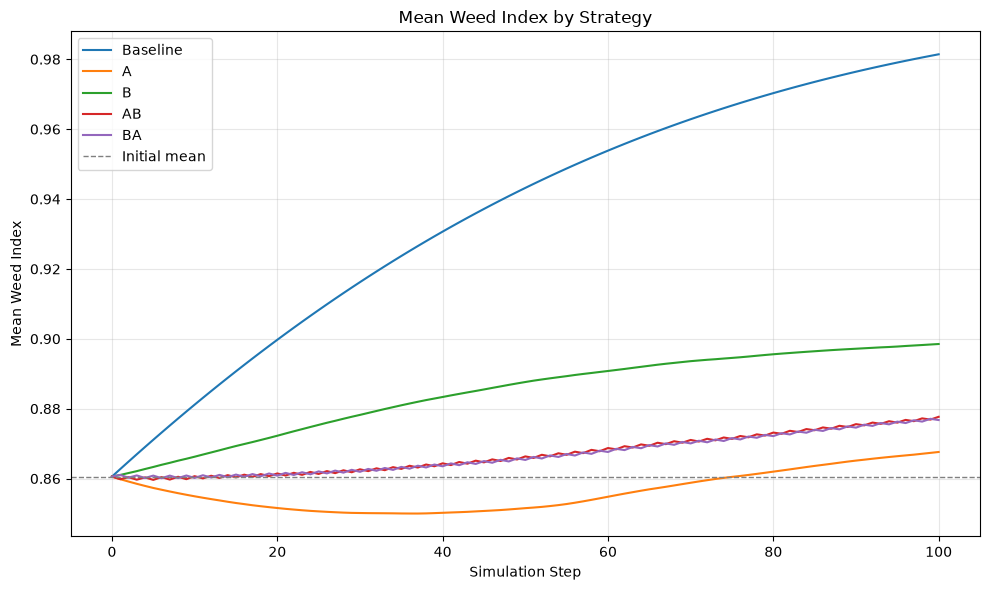

In [27]:
simulation_steps = np.arange(
    len(baseline_result.mean_weed)
)

fig, ax = plt.subplots(
    figsize=(10, 6),
)

for strategy_name, result in results.items():
    ax.plot(
        simulation_steps,
        result.mean_weed,
        label=strategy_name,
    )

ax.axhline(
    baseline_result.initial_mean,
    color="gray",
    linestyle="--",
    linewidth=1,
    label="Initial mean",
)

ax.set_title(
    "Mean Weed Index by Strategy"
)

ax.set_xlabel("Simulation Step")
ax.set_ylabel("Mean Weed Index")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

## Compare high-density cells

The high-density-cell metric counts cells whose weed index is at least
`0.7`.

Policy A and Policy B affect this metric differently:

- Policy A reduces values in already high-density cells;
- Policy B attempts to prevent medium-density cells from crossing the
  high-density threshold.

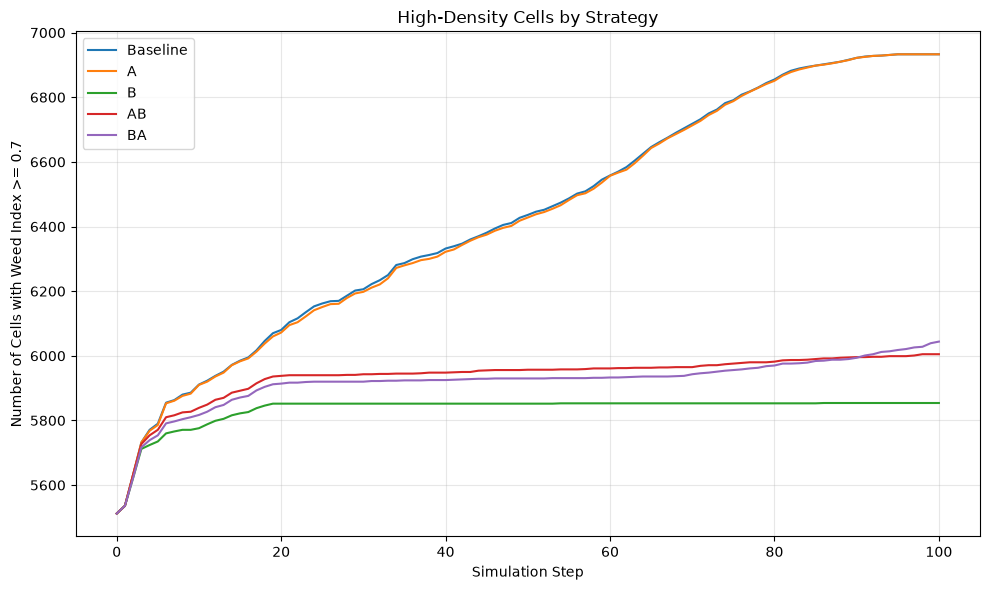

In [28]:
fig, ax = plt.subplots(
    figsize=(10, 6),
)

for strategy_name, result in results.items():
    ax.plot(
        simulation_steps,
        result.high_density_cells,
        label=strategy_name,
    )

ax.set_title(
    "High-Density Cells by Strategy"
)

ax.set_xlabel("Simulation Step")
ax.set_ylabel(
    "Number of Cells with Weed Index >= 0.7"
)

ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

## Compare cumulative cost

Every strategy has one treatment opportunity per simulation step, except
the no-removal baseline.

However, the cumulative costs may differ because:

- A and B target cells with different weed-index values;
- the number of eligible cells may differ;
- AB and BA change the grid before the other policy is applied.

Therefore, cost must be considered alongside effectiveness.

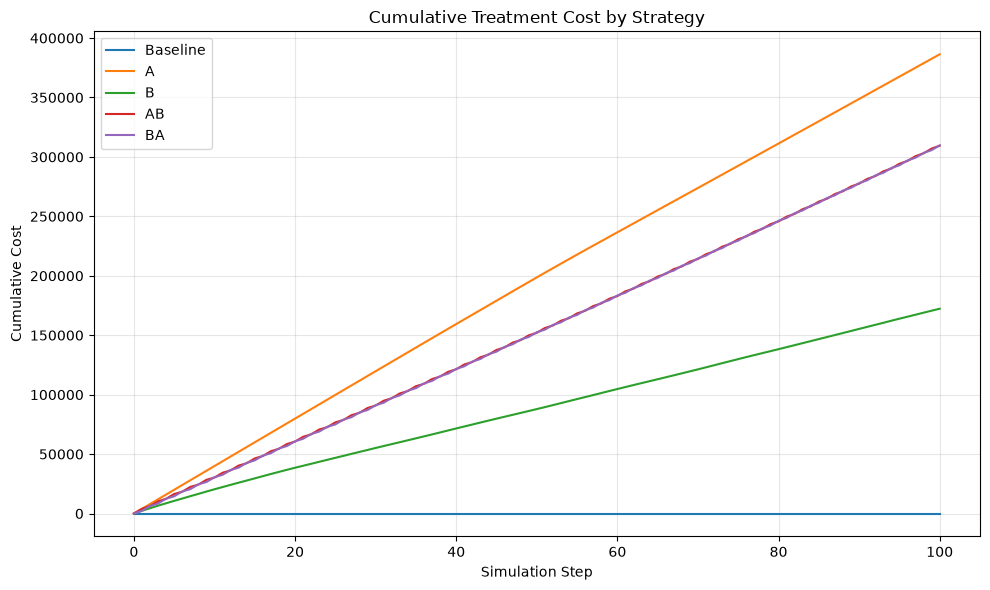

In [29]:
fig, ax = plt.subplots(
    figsize=(10, 6),
)

for strategy_name, result in results.items():
    ax.plot(
        simulation_steps,
        result.cost_history,
        label=strategy_name,
    )

ax.set_title(
    "Cumulative Treatment Cost by Strategy"
)

ax.set_xlabel("Simulation Step")
ax.set_ylabel("Cumulative Cost")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

## Compare final spatial distributions

The final grids show how each strategy changes the spatial distribution of
the weed index after 100 steps.

All panels use the same colour scale.

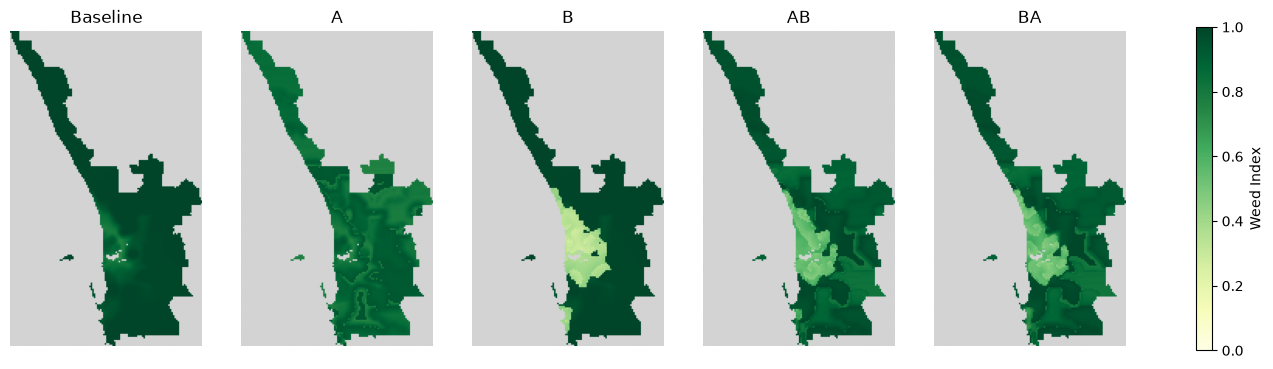

In [30]:
cmap = plt.cm.YlGn.copy()
cmap.set_bad("lightgray")

fig, axes = plt.subplots(
    nrows=1,
    ncols=5,
    figsize=(18, 7),
)

last_image = None

for ax, (strategy_name, result) in zip(
    axes,
    results.items(),
):
    last_image = ax.imshow(
        result.history[-1],
        cmap=cmap,
        vmin=0,
        vmax=1,
    )

    ax.set_title(strategy_name)
    ax.axis("off")

fig.colorbar(
    last_image,
    ax=axes,
    label="Weed Index",
    shrink=0.6,
)

plt.show()